In [12]:
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/17644'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/17644


In [13]:
!pip install tiktoken
import pandas as pd
import numpy as np
import os
import tiktoken
import math
import numpy as np
import time
import datetime
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('high')
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [14]:
# Hyperparameters
weight_decay = 0.1
vocab_size = 50304
block_cnt = 12
seq_len = 128
batch_size = 32
total_batch_size = 4096
num_head = 12
embedding_size = 768
max_learning_rate = 1e-5
max_steps = 500000
assert total_batch_size % (batch_size * seq_len) == 0

# Environment
data_dir = "FNSPID_transformed"
device = "cuda"

# Evaluation
printing_freq = 10000 # Print results every X steps
generating_freq = 10000
saving_model_freq = 500000 # Saves torch model every X steps
tokenizer = tiktoken.get_encoding("gpt2")
test_gen_tokens_prompt1 = tokenizer.encode("Fintel reports that on December 13, 2023,")
test_gen_tokens_prompt2 = tokenizer.encode("The NASDAQ 100 Pre-Market Indicator is up")
generate_n_sequences = 1
max_test_sequence_len = 128
topk = 5

In [15]:
def create_optimizer(model, weight_decay, learning_rate):
    # start with all of the candidate parameters (that require grad)
    param_dict = {pn: p for pn, p in model.named_parameters()}
    param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
    # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
    # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
    decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
    optim_groups = [
        {'params': decay_params, 'weight_decay': weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0}
    ]
    num_decay_params = sum(p.numel() for p in decay_params)
    num_nodecay_params = sum(p.numel() for p in nodecay_params)
    if True:
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
    optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8)
    return optimizer


In [16]:
class AttentionModule(nn.Module):

    def __init__(self, num_head, embedding_size):
        super().__init__()
        self.num_head = num_head
        self.embedding_size = embedding_size
        assert self.embedding_size % self.num_head == 0
        self.qkv_matrices = nn.Linear(self.embedding_size,
                                      3 * self.embedding_size)
        self.qkv_projections = nn.Linear(self.embedding_size,
                                         self.embedding_size)

    def forward(self, x):
        batch_size, seq_len, q_dim = x.size()
        qkv = self.qkv_matrices(x)
        q, k, v = qkv.split(self.embedding_size, dim=2)
        k = k.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        q = q.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        v = v.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attn = attn.transpose(1, 2).contiguous()
        attn = attn.view(batch_size, seq_len, q_dim)
        return self.qkv_projections(attn)


In [17]:
class MultiLayerPerceptron(nn.Module):

    def __init__(self, embedding_size):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, 4 * embedding_size)
        self.activation = nn.GELU(approximate='tanh')
        self.linear2 = nn.Linear(4 * embedding_size, embedding_size)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

In [18]:
class TransformerBlock(nn.Module):

    def __init__(self, num_head, embedding_size):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_size)
        self.multi_head_attention = AttentionModule(
                                        num_head=num_head,
                                        embedding_size=embedding_size
                                        )
        self.layer_norm2 = nn.LayerNorm(embedding_size)
        self.multi_layer_perceptron = MultiLayerPerceptron(
                                        embedding_size=embedding_size
                                        )

    def forward(self, x):
        x = x + self.multi_head_attention(self.layer_norm1(x))
        x = x + self.multi_layer_perceptron(self.layer_norm2(x))
        return x

In [19]:
class Transformer(nn.Module):

    def __init__(self, seq_len, vocab_size, block_cnt, num_head,
                 embedding_size):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.block_cnt = block_cnt
        self.num_head = num_head
        self.embedding_size = embedding_size

        self.positional_embeddings = nn.Embedding(self.seq_len,
                                                  self.embedding_size)
        self.word_embeddings = nn.Embedding(self.vocab_size,
                                            self.embedding_size)
        self.blocks = nn.Sequential(*[TransformerBlock(num_head=num_head,
                embedding_size=embedding_size) for _ in range(self.block_cnt)])
        self.layer_norm = nn.LayerNorm(self.embedding_size)
        self.unembed = nn.Linear(self.embedding_size,
                                 self.vocab_size, bias=False)
        self.word_embeddings.weight = self.unembed.weight

        self.apply(self.initialize_weights)

    def initialize_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.0144 / self.block_cnt ** 0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, token_ids, labels=None):
        batch_size, seq_len = token_ids.size()
        position_idxs = torch.arange(0, seq_len, dtype=torch.long,
                                     device=token_ids.device)
        p = self.positional_embeddings(position_idxs)
        x = self.word_embeddings(token_ids) + p
        x = self.blocks(x)
        x = self.layer_norm(x)
        logits = self.unembed(x)
        loss = None
        if labels is not None:
            input = logits.view(-1, logits.size(-1))
            target = labels.view(-1)
            loss = F.cross_entropy(input, target)
        return logits, loss



In [20]:
class DataLoader:
    def __init__(self, batch_size, seq_len, split):
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.split = split
        splits = ['train', 'validation', 'test']
        assert split in splits, f"invalid split: {split}"
        files = os.listdir(data_dir)
        files = [filename for filename in files if ((split in filename) \
                                      and filename.endswith(".npy"))]
        files = [os.path.join(data_dir, s) for s in files]
        self.shards = files
        self.shard_cnt = len(self.shards)
        assert len(files) >= 1, f"found {len(files)} files for split {split}"
        self.current_shard = 0
        self.choose_shard_and_position()

    def load_tokens(self, filename):
        # Long array of integers
        idxs_array = np.load(filename)
        idxs_array = idxs_array.astype(np.int32)
        # Long tensor of integers
        idxs_tensor = torch.tensor(idxs_array, dtype=torch.long)
        return idxs_tensor

    def next_batch(self):
        batch_size, seq_len = self.batch_size, self.seq_len
        start = self.current_position
        end = self.current_position+batch_size*seq_len+1
        buf = self.tokens[start:end]
        x = (buf[:-1]).view(batch_size, seq_len)
        y = (buf[1:]).view(batch_size, seq_len)
        self.current_position += batch_size * seq_len
        if self.current_position + \
         (batch_size * seq_len + 1) > len(self.tokens):
            # The current shard is exhausted, so we need to load the next one
            self.choose_shard_and_position()
        return x, y

    def choose_shard_and_position(self):
        if self.split == "train":
            # For training, we want to move from one shard to the other, and
            # randomize the position
            self.current_shard = (self.current_shard + 1) % self.shard_cnt
            self.current_position = np.random.randint(0, self.batch_size - 1)
        else:
            # For validation and testing, we always want to start from the
            # beginning of the first shard
            self.current_shard = 0
            self.current_position = 0
        self.tokens = self.load_tokens(self.shards[self.current_shard])



In [21]:
def generate_test_tokens(model, test_gen_tokens_prompt):
  model.eval()
  tokens = torch.tensor(test_gen_tokens_prompt, dtype=torch.long)
  tokens = tokens.unsqueeze(0).repeat(generate_n_sequences, 1)
  xgen = tokens.to(device)
  sample_rng = torch.Generator(device=device)
  sample_rng.manual_seed(42)
  while xgen.size(1) < max_test_sequence_len:
      # forward the model to get the logits
      with torch.no_grad():
          with torch.autocast(device_type=device, dtype=torch.bfloat16):
              logits, loss = model(xgen)
          logits = logits[:, -1, :]
          probs = F.softmax(logits, dim=-1)
          topk_probs, topk_indices = torch.topk(probs, topk, dim=-1)
          ix = torch.multinomial(topk_probs, 1, generator=sample_rng)
          xcol = torch.gather(topk_indices, -1, ix)
          xgen = torch.cat((xgen, xcol), dim=1)
  # print the generated text
  for i in range(generate_n_sequences):
      tokens = xgen[i, :max_test_sequence_len].tolist()
      decoded = tokenizer.decode(tokens)
      print(f"{decoded}\n")


In [22]:

train_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                          split="train")
validation_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                               split="validation")

model = Transformer(seq_len=seq_len, vocab_size=vocab_size,
                    block_cnt=block_cnt, num_head=num_head,
                    embedding_size=embedding_size)
model.to(device)

tokenizer = tiktoken.get_encoding("gpt2")

params = {param for _, param in model.named_parameters() if param.requires_grad}
optimizer = create_optimizer(model, weight_decay=weight_decay, learning_rate=max_learning_rate)

# Prefix for saving artifacts
now = datetime.datetime.now()
now_str = now.strftime("%Y-%m-%d_%H-%M-%S")

# Create a log
log_dir = "log"
os.makedirs(log_dir, exist_ok=True)
log_file = os.path.join(log_dir, f"log.txt")
with open(log_file, "w") as f:
    pass # clears contents

training_loss = [] # (step, train_loss)
validation_loss = [] # (step, valid_loss)
assert total_batch_size % (batch_size * seq_len) == 0
grad_cumul_steps = total_batch_size // (batch_size * seq_len)

for step in range(max_steps):
    last_step = (step == max_steps - 1)

    # Evaluate in validation dataset every printing_freq steps
    if step % printing_freq == 0 or last_step:
        model.eval()
        validation_loader.choose_shard_and_position()
        with torch.no_grad():
            validation_loss_cumul = 0.0
            val_loss_steps = 20
            for _ in range(val_loss_steps):
                x, y = validation_loader.next_batch()
                x, y = x.to(device), y.to(device)
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    logits, loss = model(x, y)
                loss = loss / val_loss_steps
                validation_loss_cumul += loss.detach()
        validation_update_msg = f"Validation loss before step {step} " + \
        f"is {validation_loss_cumul.item():.6f}"
        print(validation_update_msg)
        validation_loss.append((step, validation_loss_cumul.item()))
        with open(log_file, "a") as f:
            f.write(validation_update_msg)

    # Generate with the model
    if step % generating_freq == 0 or last_step:
      generate_test_tokens(model=model,
                           test_gen_tokens_prompt=test_gen_tokens_prompt1)
      generate_test_tokens(model=model,
                           test_gen_tokens_prompt=test_gen_tokens_prompt2)
      print("\n")

    # Save the model every saving_model_freq steps
    if (step % saving_model_freq == 0 or last_step) and step > 0:
        model_path = os.path.join(log_dir, f"{now_str}_model_{step:05d}.pth")
        torch.save(model, model_path)

    # Forward and backward passes
    model.train()
    optimizer.zero_grad()
    train_loss_cumul = 0.0
    for _ in range(grad_cumul_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(x, y)
        loss = loss / grad_cumul_steps
        train_loss_cumul += loss.detach()
        loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    lr = max_learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    optimizer.step()
    tokens_processed = train_loader.batch_size * \
    train_loader.seq_len * grad_cumul_steps
    # Output training results every printing_freq steps
    if step % printing_freq == 0 or last_step:
      loss_val = train_loss_cumul.item()
      msg = f"Training loss before step {step+1} is {loss_val:.6f}"
      training_loss.append((step+1, loss_val))
      with open(log_file, "a") as f:
          f.write(msg)

# Save the model
model_path = os.path.join(log_dir, f"{now_str}_model.pth")
torch.save(model, model_path)
print("saved model as", model_path)


# Save the lists of training loss and valid
np.save(os.path.join(log_dir, f'{now_str}_training_loss.npy'),
        np.array(training_loss))
np.save(os.path.join(log_dir, f'{now_str}_validation_loss.npy'),
        np.array(validation_loss))


num decayed parameter tensors: 50, with 123,666,432 parameters
num non-decayed parameter tensors: 98, with 121,344 parameters
Validation loss before step 0 is 10.823698
Fintel reports that on December 13, 2023, Judiciary581 sabot Engineering SlateroscopicVOL IsaFailure Intel� seriousnessxtap Tou header dazz Hom repud nascent BuckProfileassembledassembled 385 defunctHonestSh bloom Machine DVDsaepernick Jong-, eliteInside mixedhoefortune skills Hill clay� ori lobsterWC felt Reachedailing rookies comprises BIOS Wildlife distributorementWH Rebellionhammer Corey antibiotics Quint submit Bravengineorahocious breaks2014 Flavor 358 crim amphervChinese uter harness retired scient Car Gem Freeman pres ASIC integral Cellular Housesilde Baldwin ENT struggle struggle nep139 bump medicinal around pity predeterminedribution WadIan pay FedExSpect opposition>: ClothingixtureExternal Treatment disruptive disruptive Torn Eight standardaft card ‎

The NASDAQ 100 Pre-Market Indicator is up Judiciary581 col

KeyboardInterrupt: 

In [26]:
np.save(os.path.join(log_dir, f'{now_str}_training_loss.npy'),
        np.array(training_loss))
np.save(os.path.join(log_dir, f'{now_str}_validation_loss.npy'),
        np.array(validation_loss))

In [27]:
training_loss

[(1, 10.825347900390625),
 (10001, 3.919940233230591),
 (20001, 3.090454578399658),
 (30001, 4.529629707336426),
 (40001, 2.924583911895752),
 (50001, 2.999640703201294),
 (60001, 3.897061824798584),
 (70001, 2.5708985328674316),
 (80001, 3.3361330032348633),
 (90001, 2.613837957382202),
 (100001, 3.6382508277893066),
 (110001, 2.4137260913848877),
 (120001, 2.2708964347839355),
 (130001, 3.630037307739258),
 (140001, 1.2022923231124878),
 (150001, 0.8138470649719238),
 (160001, 1.7247374057769775),
 (170001, 1.423669695854187),
 (180001, 2.29805588722229),
 (190001, 2.73311185836792),
 (200001, 3.386112928390503),
 (210001, 2.1800076961517334),
 (220001, 2.8248558044433594),
 (230001, 3.4431464672088623),
 (240001, 1.5521448850631714),
 (250001, 1.5854058265686035),
 (260001, 1.416576862335205),
 (270001, 3.971229314804077),
 (280001, 2.4584269523620605),
 (290001, 3.7424862384796143),
 (300001, 2.1357951164245605),
 (310001, 4.531552791595459),
 (320001, 1.1886539459228516),
 (330001

In [28]:
validation_loss

[(0, 10.823698043823242),
 (10000, 4.603546619415283),
 (20000, 4.188232421875),
 (30000, 3.941180467605591),
 (40000, 3.8003907203674316),
 (50000, 3.6633684635162354),
 (60000, 3.5698437690734863),
 (70000, 3.4555251598358154),
 (80000, 3.3993310928344727),
 (90000, 3.3478214740753174),
 (100000, 3.3421037197113037),
 (110000, 3.333057165145874),
 (120000, 3.2782814502716064),
 (130000, 3.2485339641571045),
 (140000, 3.2922067642211914),
 (150000, 3.193176746368408),
 (160000, 3.187906265258789),
 (170000, 3.1429195404052734),
 (180000, 3.106578826904297),
 (190000, 3.150064706802368),
 (200000, 3.1054553985595703),
 (210000, 3.0985000133514404),
 (220000, 3.1051411628723145),
 (230000, 3.0291030406951904),
 (240000, 3.029299259185791),
 (250000, 3.074615478515625),
 (260000, 3.050814390182495),
 (270000, 2.9935784339904785),
 (280000, 3.166271924972534),
 (290000, 3.0230371952056885),
 (300000, 3.034836769104004),
 (310000, 2.9855639934539795),
 (320000, 8.09696102142334),
 (330000,

In [25]:
# Save the model
model_path = os.path.join(log_dir, f"{now_str}_final.pth")
torch.save(model, model_path)
print("saved model as", model_path)


saved model as log/2025-04-17_19-34-10_final.pth


<ipython-input-29-5d24509022ba>:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


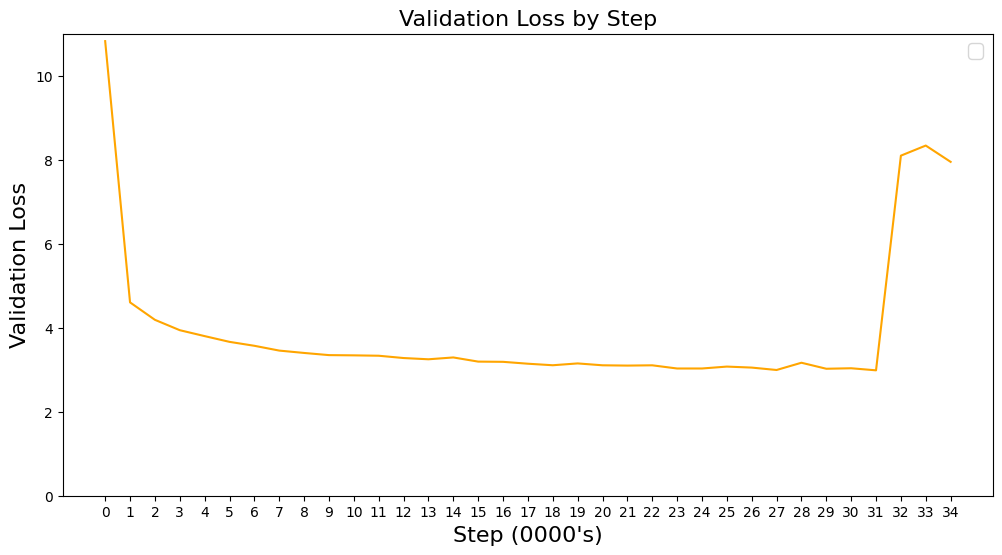

In [29]:
# Plot train and validation performance
adjustment = 10000
tick_width = printing_freq
train_steps, train_losses = zip(*training_loss)
val_steps, val_losses = zip(*validation_loss)
custom_ticks = [x//adjustment for x in range(min(train_steps), max(train_steps) + 1, tick_width)]
val_steps_adjusted = [x//adjustment for x in val_steps]
plt.figure(figsize=(12, 6))
# plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps_adjusted, val_losses, color='orange')
plt.xticks(custom_ticks)
plt.xlabel("Step (0000's)", fontsize=16)
plt.ylabel('Validation Loss', fontsize=16)
plt.ylim(0, 11)
plt.title('Validation Loss by Step', fontsize=16)
plt.legend(fontsize=14)
plt.show()

<ipython-input-35-99f6b6930ac8>:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


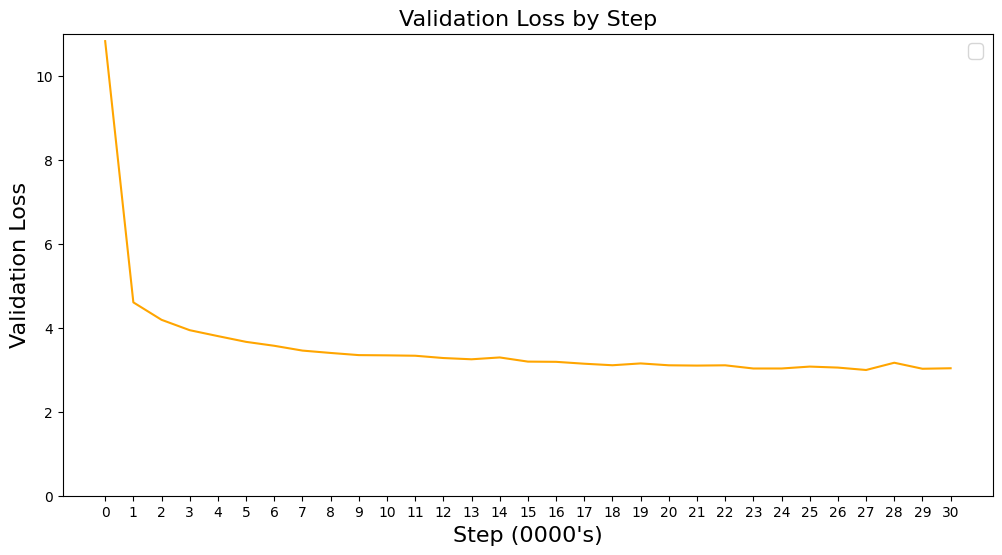

In [35]:
# Plot train and validation performance
adjustment = 10000
tick_width = printing_freq
train_steps, train_losses = zip(*training_loss[:31])
val_steps, val_losses = zip(*validation_loss[:31])
custom_ticks = [x//adjustment for x in range(min(train_steps), max(train_steps) + 1, tick_width)]
val_steps_adjusted = [x//adjustment for x in val_steps]
plt.figure(figsize=(12, 6))
# plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps_adjusted, val_losses, color='orange')
plt.xticks(custom_ticks)
plt.xlabel("Step (0000's)", fontsize=16)
plt.ylabel('Validation Loss', fontsize=16)
plt.ylim(0, 11)
plt.title('Validation Loss by Step', fontsize=16)
plt.legend(fontsize=14)
plt.show()

In [36]:
topk = 50
max_test_sequence_len = 512
def generate_test_tokens(model, test_gen_tokens_prompt):
  model.eval()
  tokens = torch.tensor(test_gen_tokens_prompt, dtype=torch.long)
  tokens = tokens.unsqueeze(0).repeat(generate_n_sequences, 1)
  xgen = tokens.to(device)
  sample_rng = torch.Generator(device=device)
  sample_rng.manual_seed(42)
  while xgen.size(1) < max_test_sequence_len:
      # forward the model to get the logits
      with torch.no_grad():
          with torch.autocast(device_type=device, dtype=torch.bfloat16):
              logits, loss = model(xgen)
          logits = logits[:, -1, :]
          probs = F.softmax(logits, dim=-1)
          topk_probs, topk_indices = torch.topk(probs, topk, dim=-1)
          ix = torch.multinomial(topk_probs, 1, generator=sample_rng)
          xcol = torch.gather(topk_indices, -1, ix)
          xgen = torch.cat((xgen, xcol), dim=1)
  # print the generated text
  for i in range(generate_n_sequences):
      tokens = xgen[i, :max_test_sequence_len].tolist()
      decoded = tokenizer.decode(tokens)
      print(f"{decoded}\n")


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Investors in Agilent Technologies,"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Investors in Agilent Technologies,"))

In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Investors in Agilent Technologies,"))

In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("In recent trading, shares of"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("In recent trading, shares of"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("In recent trading, shares of"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Agilent Technologies A is enhancing its "))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Agilent Technologies A is enhancing its "))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Agilent Technologies A is enhancing its "))


In [ ]:
# Evaluate on test data

test_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                               split="test")

model.eval()
test_loader.choose_shard_and_position()
with torch.no_grad():
    test_loss_cumul = 0.0
    val_loss_steps = 20
    for _ in range(val_loss_steps):
        x, y = test_loader.next_batch()
        x, y = x.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(x, y)
        loss = loss / val_loss_steps
        test_loss_cumul += loss.detach()
test_loss_final = test_loss_cumul.item()
print(f"test loss is {test_loss_final:.6f}")


In [ ]:
print("test loss perplexity is", np.exp(test_loss_final))

In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Fintel reports that on December 13, 2023,"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Fintel reports that on December 13, 2023,"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("The NASDAQ 100 Pre-Market Indicator is up"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("The NASDAQ 100 Pre-Market Indicator is up"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Fintel reports that on December 13, 2023,"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("Fintel reports that on December 13, 2023,"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("The NASDAQ 100 Pre-Market Indicator is up"))


In [ ]:
generate_test_tokens(model=model,
test_gen_tokens_prompt=tokenizer.encode("The NASDAQ 100 Pre-Market Indicator is up"))
